In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import numpy as np
import pandas as pd

# NumPy arrays
np.set_printoptions(suppress=True, precision=4) # Display NumPy arrays without scientific notation and round to 4 decimal places

# Pandas DataFrames
pd.set_option("display.float_format", "{:.6f}".format)

data = load_breast_cancer(as_frame=True)
df = data.frame

X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps the same class distribution in the training and test sets.
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [2]:
pred =  model.predict(X_test)
proba = model.predict_proba(X_test)

pred[:5]

array([0, 1, 0, 1, 0])

In [3]:
proba[:5]

array([[1.    , 0.    ],
       [0.    , 1.    ],
       [0.9493, 0.0507],
       [0.3959, 0.6041],
       [1.    , 0.    ]])

In [4]:
results = X_test.copy()

results["actual"] = y_test.values
results["predicted"] = pred
results["prob_malignant"] = proba[:,0]
results["prob_benign"] = proba[:,1]

results[
    ["actual", "predicted", "prob_malignant", "prob_benign"]
].head(10)

,actual,predicted,prob_malignant,prob_benign
256,0,0,1.000000,0.000000
428,1,1,0.000035,0.999965
501,0,0,0.949319,0.050681
363,1,1,0.395873,0.604127
564,0,0,1.000000,0.000000
464,1,1,0.017420,0.982580
358,1,1,0.000029,0.999971
343,0,0,0.999990,0.000010
516,0,0,0.999951,0.000049
567,0,0,1.000000,0.000000


### Adjusting Threshold

In [5]:
malignant_prob = proba[:,0]

pred_05 = (malignant_prob >= 0.5).astype(int)
pred_05

array([1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0])

In [6]:
malignant_prob

array([1.    , 0.    , 0.9493, 0.3959, 1.    , 0.0174, 0.    , 1.    ,
       1.    , 1.    , 0.0014, 0.9951, 0.0009, 1.    , 0.9994, 0.0608,
       0.7796, 0.0213, 0.0014, 0.0207, 0.9961, 0.9876, 0.0003, 0.0007,
       0.0286, 0.0644, 1.    , 0.0055, 0.0015, 0.0033, 0.0346, 0.0002,
       0.0374, 0.0007, 1.    , 0.2719, 0.0007, 0.0004, 0.1253, 1.    ,
       0.0004, 0.0003, 0.0476, 1.    , 0.9973, 0.4934, 0.    , 0.    ,
       0.0188, 0.9986, 0.0021, 0.443 , 0.0001, 0.2935, 0.0116, 0.0016,
       0.0001, 0.9992, 1.    , 0.0108, 0.0079, 0.    , 0.0007, 0.0581,
       1.    , 0.2324, 0.1958, 0.0068, 0.2265, 0.0309, 0.0041, 0.0137,
       0.    , 1.    , 0.9983, 1.    , 0.7518, 0.0018, 0.001 , 0.0102,
       0.1467, 0.0003, 1.    , 0.0002, 0.6315, 0.004 , 0.0128, 0.0001,
       0.1025, 0.0739, 0.1011, 0.0173, 1.    , 0.9997, 0.9976, 0.    ,
       1.    , 0.0008, 1.    , 0.1419, 0.9999, 1.    , 0.8884, 0.0132,
       1.    , 1.    , 0.0034, 1.    , 0.0001, 1.    , 0.0578, 0.9895,
      

In [7]:
y_test_malignant = (y_test == 0).astype(int)
y_test_malignant

256    1
428    0
501    1
363    0
564    1
      ..
95     1
128    0
257    1
228    0
488    0
Name: target, Length: 114, dtype: int64

In [8]:
y_test

256    0
428    1
501    0
363    1
564    0
      ..
95     0
128    1
257    0
228    1
488    1
Name: target, Length: 114, dtype: int64

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Threshold 0.5")
print("Precision: ", precision_score(y_test_malignant, pred_05))
print("Recall: ", recall_score(y_test_malignant, pred_05))
print("F1: ", f1_score(y_test_malignant, pred_05))

Threshold 0.5
Precision:  0.975
Recall:  0.9285714285714286
F1:  0.9512195121951219


In [10]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    pred_t = (malignant_prob >= t).astype(int)

    precision = precision_score(y_test_malignant, pred_t)
    recall = recall_score(y_test_malignant, pred_t)

    print(
        f"Threshold: {t}, "
        f"Precision: {precision:.3f}, "
        f"Recall: {recall:.3f}"
)

Threshold: 0.2, Precision: 0.894, Recall: 1.000
Threshold: 0.3, Precision: 0.907, Recall: 0.929
Threshold: 0.4, Precision: 0.929, Recall: 0.929
Threshold: 0.5, Precision: 0.975, Recall: 0.929
Threshold: 0.6, Precision: 0.975, Recall: 0.929
Threshold: 0.7, Precision: 0.974, Recall: 0.905


### ROC-AUC

In [11]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test_malignant,
    malignant_prob
)

print("ROC-AUC: ", auc)

ROC-AUC:  0.9953703703703703


* ROC: Receiver Operating Characteristic
* AUC: Area Under the Curve
* ROC-AUC measures how well the model separates the positive class from the negative class across different classification thresholds.

1. What does predict_proba() return?
* predic_proba() returns the predicted probability for each class.

2. What is a classification threshold?
* A classification threshold is the cutoff used to decide which class a prediction belongs to.

3. Why might we lower the threshold?
* We might lower the threshold to catch more positive cases and increase recall.

4. What is the trade-off between precision and recall?
* Increasing recall often lowers precision, while increasing precision can lower recall.

In [12]:
pred_03 = (malignant_prob >= 0.3).astype(int)
pred_07 = (malignant_prob >= 0.7).astype(int)

In [13]:
from sklearn.metrics import confusion_matrix

print("Threshold 0.3")
print(confusion_matrix(y_test_malignant, pred_03))
print("Threshold 0.7")
print(confusion_matrix(y_test_malignant, pred_07))

Threshold 0.3
[[68  4]
 [ 3 39]]
Threshold 0.7
[[71  1]
 [ 4 38]]


[[TN, FP],

 [FN, TP]]

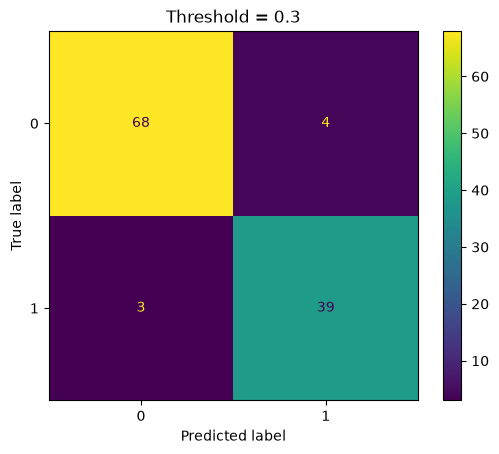

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_malignant,
    pred_03
)

plt.title("Threshold = 0.3")
plt.show()

In [15]:
import sklearn
print(sklearn.__version__)
print(sklearn.__file__)

1.9.1
/Users/youjin/ai-career/.venv/lib/python3.12/site-packages/sklearn/__init__.py


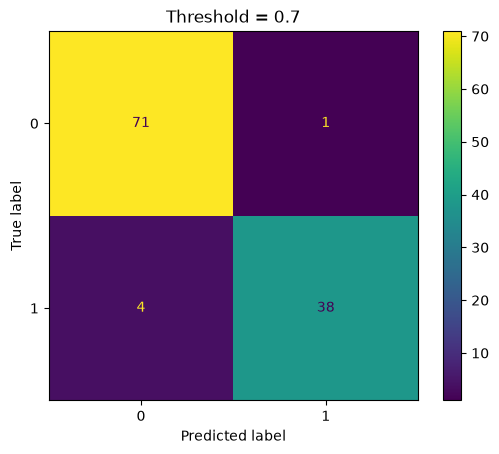

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test_malignant,
    pred_07
)

plt.title("Threshold = 0.7")
plt.show()

In [19]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test_malignant,
    malignant_prob
)

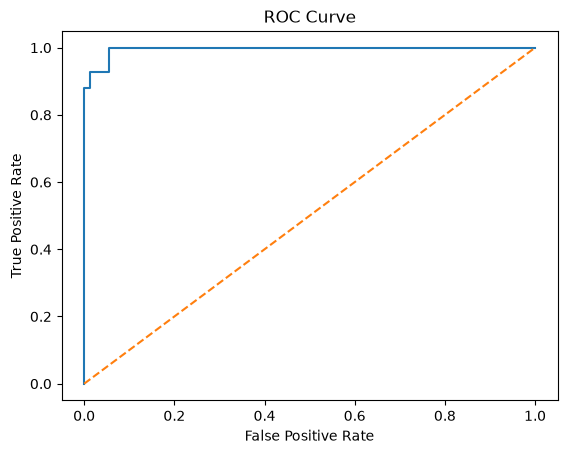

In [22]:
plt.plot(fpr, tpr)
plt.plot([0, 1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

* X: It indicates how many negatives the model predicted as positive.
* Y (=recall): It indicates how many positives the model predicted correctly.

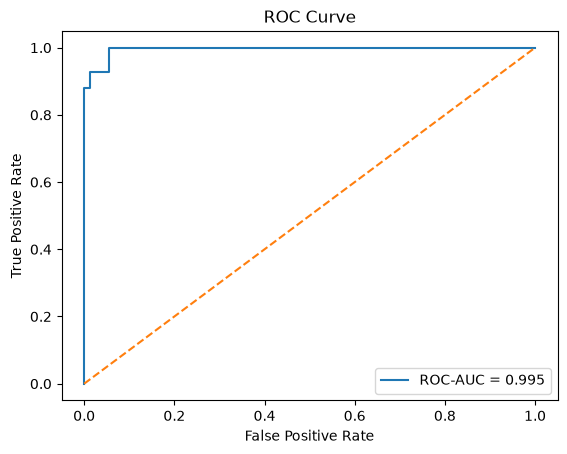

In [25]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test_malignant,
    malignant_prob
)

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

* ROC-AUC: ROC-AUC measures how well a model distinguishes between the positive and negative classes across all classification thresholds, rather than relying on a single threshold.

1. What is a false negative?
* A false negative occurs when an actual positive case is incorrectly classified as negative by the model.

2. What happens to false negatives when we lower the threshold?
* When we lower the threshold, the number of false negatives usually decreses.

3. What does the x-axis of the ROC curve represent?
* The x-axis of the ROC curve represents the false positive rate.

4. What does the y-axis of the ROC curve represent?
* The y-axis of the ROC curve represents the true positive rate.

5. Why is a ROC curve closer to the top-left corner better?
* A ROC curve closer to the top-left corner is better because it indicates a high true positive rate with a low false positive rate.